(02-07-event-studies)=

# De event study

```{admonition} Waar we zijn in het verhaal
:class: important

**Jaartal.** 1968–1997: van de eerste event studies op de CRSP-tape tot het
methodologische overzicht van MacKinlay.

**Wat we al weten.** [De vorige lecture](#02-06-efficiente-markten) formuleerde
de efficiënte-marktheorie van Fama: prijzen weerspiegelen alle beschikbare
informatie, en elke toets daarvan is tegelijk een toets van een model voor het
"normale" rendement — de joint hypothesis. De toetsen daar keken naar
autocorrelaties in de rendementen zelf, de zwakke vorm. De machine lag klaar:
een maandelijkse rendementstape voor elk NYSE-aandeel sinds 1926.

**Welke vraag staat open.** Hoe snel en hoe volledig verwerkt een prijs een
specifiek, publiek nieuwsfeit — en hoe meet je dat, als je niet weet wat het
aandeel zonder dat nieuws zou hebben gedaan?
```

## Overzicht

Tot het eind van de jaren zestig ging de discussie over efficiënte markten over
reeksen: is het rendement van morgen te voorspellen uit dat van vandaag? Dat is
een zwakke toets, want hij zegt niets over de vraag waar het de econoom om gaat,
namelijk of prijzen *nieuws* goed verwerken. Twee artikelen veranderden dat
binnen een jaar. {cite:t}`BallBrown1968` keken naar winstaankondigingen en
vroegen of de koers bewoog vóór, tijdens of na de maand van publicatie. Hun
antwoord was dat het jaarcijfer geen tijdig medium is: *"most of its content
(about 85 to 90 per cent) is captured by more prompt media"* (p. 176).
{cite:t}`FamaFisherJensenRoll1969` (FFJR) keken naar aandelensplitsingen en
bouwden daarbij het instrument dat sindsdien *event study* heet (een studie
van het koersgedrag rond een gebeurtenis in *eventtijd*: alle gebeurtenissen
worden op dag of maand nul gelegd, ongeacht de kalenderdatum, en de afwijking
van het normale rendement wordt gemiddeld). Het instrument is zo eenvoudig dat
het onzichtbaar is geworden: {cite:t}`KothariWarner2007` telden in vijf
financetijdschriften tussen 1974 en 2000 al 565 artikelen met
event-study-resultaten. Het idee zelf is ouder:
{cite:t}`MacKinlay1997` noemt {cite:t}`Dolley1933` als waarschijnlijk eerste
gepubliceerde studie, met 95 splitsingen tussen 1921 en 1931, waarvan de koers in
57 gevallen steeg en in 26 daalde. Wat FFJR toevoegden, waren de correctie voor
de markt en het middelen in eventtijd.

We behandelen de event study als meetinstrument, met het overzicht van
{cite:t}`MacKinlay1997` als referentie: het abnormale rendement, de variantie
van een cumulatief abnormaal rendement inclusief schattingsfout, en de toetsen
$J_1$, {cite:t}`Patell1976` en {cite:t}`BoehmerMusumeciPoulsen1991`. De simulatie
volgt {cite:t}`BrownWarner1980,BrownWarner1985` en laat daarna zien wat clustering
van eventdatums doet, het probleem van {cite:t}`KolariPynnonen2010`.

De replicatie is een event study in de geest van FFJR op 102
aandelensplitsingen van grote Amerikaanse aandelen tussen 2004 en 2025. Het
gepubliceerde patroon van FFJR — een sterke stijging van het cumulatieve
abnormale rendement in de maanden vóór de splitsing, en een vlakke lijn daarna
— is de falsifieerbare verwachting.

De epistemische status van de event study is die van een meetinstrument met een
ingebouwde aanname. Wat gemeten wordt is altijd een afwijking *ten opzichte van
een model* voor het normale rendement. Op een horizon van dagen doet dat model
er nauwelijks toe; op een horizon van jaren bepaalt het de uitkomst. Dat
verschil zal aan het eind van deze lecture de brug zijn naar het eerste serieuze
model voor het normale rendement: het CAPM.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import hap
from hap import data as hap_data
hap.plotting.setup()

rng = np.random.default_rng(20240101)

## Intuïtie: waarom zou dit waar zijn?

Een aandelensplitsing verandert niets. Een bedrijf dat één aandeel van 400 dollar
vervangt door vier aandelen van 100 dollar, heeft dezelfde fabrieken, dezelfde
winst en dezelfde eigenaren. Een pizza in acht punten is niet groter dan een
pizza in vier. Als de markt rationeel is, zou de totale waarde van het bedrijf
op de splitsingsdatum dus niet mogen veranderen.

En toch is een splitsing niet informatieloos. Bedrijven splitsen hun aandelen
vooral nadat de koers flink is gestegen, en ze doen het vaak tegelijk met een
dividendverhoging of in een periode waarin het management vertrouwen heeft in de
toekomst. De aankondiging kan dus iets *zeggen*, ook al *doet* ze niets. FFJR
zagen daarin een ideaal laboratorium: een gebeurtenis zonder directe economische
inhoud, maar met mogelijke informatie-inhoud. Als de markt efficiënt is, moet
alle informatie op het moment van aankondiging in de prijs komen, en daarna
niet meer. Wie het aandeel koopt op de dag dat de splitsing ingaat, mag er dan
geen bijzonder rendement meer mee verdienen.

Om dat te toetsen moet één probleem worden opgelost: wat zou het aandeel hebben
gedaan *zonder* het nieuws? Als de hele markt die maand 5% stijgt en het aandeel
6%, dan is het nieuws hooguit 1% waard, niet 6%. Het antwoord van FFJR was het
marktmodel. Schat over een periode zonder nieuws hoe sterk het aandeel met de
markt meebeweegt, en gebruik die relatie als tegenfeitelijk scenario. Het
verschil tussen het werkelijke rendement en dat scenario is het *abnormale
rendement*. Tel die abnormale rendementen op over de dagen of maanden rond het
event, en je krijgt het *cumulatieve abnormale rendement* (CAR).

Eén event zegt vrijwel niets. Een aandeel beweegt op een gewone dag 1 à 2% om
redenen die niemand kent; een nieuwsfeit ter waarde van 1% verdwijnt in die ruis.
De truc van de event study is middelen. Leg honderd splitsingen, uit honderd
verschillende jaren, op dag nul naast elkaar. De ruis is per event onafhankelijk
en middelt weg met $\sqrt{N}$; het signaal staat bij elk event op dezelfde dag en
middelt niet weg. Het is hetzelfde principe als het 2%-motief uit
[de lecture over rendementen](#00-01-rendementen), maar dit keer in het voordeel van
de onderzoeker. Het gemiddelde marktrendement van 6% per jaar is per dag een
signaal van ongeveer 0,02% tegen een ruis van 1%; een nieuwsfeit van 1% op een
bekende dag is een signaal van 1% tegen een ruis van 2%. Dezelfde wortel-$N$,
maar een signaal-ruisverhouding die honderd keer gunstiger is.

Die redenering heeft twee zwakke plekken. De ruis middelt alleen weg als hij
onafhankelijk is; vallen alle events op dezelfde dag, dan niet. En het
tegenfeitelijke scenario is een model: over drie dagen maakt een klein foutje
niets uit, over drie jaar stapelt het zich op tot een abnormaal rendement dat er
niet is.

FFJR vonden dat de koers vóór de splitsing sterk steeg en daarna niets
bijzonders meer deed: de markt had de informatie al verwerkt. *Hoe snel* konden
ze met maanddata niet zien. Dat is het tweede thema: de halfwaardetijd van
informatie. Santa-Clara vat de literatuur samen als: prijzen absorberen publieke
informatie binnen uren {cite}`SantaClara2026`, en *"the event-study half-lives
that were days in 1969 and hours in 2000 are now seconds for anything in a
filing, a transcript or a satellite image."*

## Toy-voorbeeld: drie aandelen, vijf plus drie dagen

Drie aandelen, A, B en C, hebben elk een event op dag $\tau = 0$. We schatten het
marktmodel op een *schattingsvenster* van vijf dagen ($\tau = -6, \dots, -2$) en
meten abnormale rendementen in een *eventvenster* van drie dagen
($\tau = -1, 0, +1$). Alle rendementen staan in procenten.

| $\tau$ | $-6$ | $-5$ | $-4$ | $-3$ | $-2$ | | $-1$ | $0$ | $+1$ |
|---|---|---|---|---|---|---|---|---|---|
| markt $R_m$ | $-2{,}0$ | $-1{,}0$ | $0{,}0$ | $1{,}0$ | $2{,}0$ | | $1{,}0$ | $-1{,}0$ | $1{,}0$ |
| A | $-1{,}4$ | $-1{,}4$ | $0{,}1$ | $0{,}6$ | $2{,}6$ | | $1{,}5$ | $1{,}0$ | $1{,}3$ |
| B | $-1{,}0$ | $0{,}0$ | $-1{,}0$ | $1{,}0$ | $1{,}0$ | | $0{,}5$ | $1{,}5$ | $0{,}5$ |
| C | $-3{,}3$ | $-0{,}8$ | $0{,}2$ | $2{,}2$ | $2{,}7$ | | $2{,}0$ | $0{,}5$ | $1{,}1$ |

**Stap 1: het marktmodel.** De marktrendementen in het schattingsvenster hebben
gemiddelde $\hat\mu_m = 0$ en kwadratensom $\sum (R_m - \hat\mu_m)^2 = 10$. Met
een gemiddelde van nul valt OLS uiteen in twee losse sommen:
$\hat\alpha_i = \bar R_i$ en $\hat\beta_{i,m} = \sum R_m R_i / 10$. Voor A is
$\bar R_A = 0{,}5/5 = 0{,}1$ en
$\sum R_m R_A = 2{,}8 + 1{,}4 + 0 + 0{,}6 + 5{,}2 = 10$, dus $\hat\beta_{A,m} = 1{,}0$.
Op dezelfde manier: $\hat\alpha_B = 0$, $\hat\beta_{B,m} = 0{,}5$ en
$\hat\alpha_C = 0{,}2$, $\hat\beta_{C,m} = 1{,}5$.

De residuen van A zijn $(0{,}5;\ -0{,}5;\ 0;\ -0{,}5;\ 0{,}5)$, met
kwadratensom $1$; gedeeld door $L_1 - 2 = 3$ vrijheidsgraden geeft dat
$\hat\sigma^2_A = 0{,}3333$. Voor B en C: $\hat\sigma^2_B = 1{,}5/3 = 0{,}5$ en
$\hat\sigma^2_C = 0{,}3333$.

**Stap 2: abnormale rendementen.** $\widehat{AR}_{i,\tau} = R_{i,\tau} -
\hat\alpha_i - \hat\beta_{i,m} R_{m,\tau}$. Voor A op dag 0:
$1{,}0 - 0{,}1 - 1{,}0 \times (-1{,}0) = 1{,}9$. Alle negen:

| | $\widehat{AR}_{-1}$ | $\widehat{AR}_{0}$ | $\widehat{AR}_{+1}$ | $\widehat{CAR}$ |
|---|---|---|---|---|
| A | $0{,}4$ | $1{,}9$ | $0{,}2$ | $2{,}5$ |
| B | $0{,}0$ | $2{,}0$ | $0{,}0$ | $2{,}0$ |
| C | $0{,}3$ | $1{,}8$ | $-0{,}6$ | $1{,}5$ |

Het gemiddelde abnormale rendement op dag 0 is $1{,}9\%$; het gemiddelde CAR
over de drie dagen, de CAAR, is precies $2{,}0\%$.

**Stap 3: de variantie van een CAR.** De naïeve variantie is $L_2 \hat\sigma^2_i
= 3\hat\sigma^2_i$: drie dagen onafhankelijke ruis. Maar $\hat\alpha_i$ en
$\hat\beta_{i,m}$ zijn geschat op vijf waarnemingen, en die schattingsfout zit in
alle drie de abnormale rendementen tegelijk. De theorie hieronder geeft de
correctie [](#eq-eventstudies-varcar):
$L_2 + L_2^2/L_1 + (\sum_{\text{event}} R_m - L_2\hat\mu_m)^2 / \sum(R_m -
\hat\mu_m)^2 = 3 + 9/5 + 1/10 = 4{,}9$. De variantie van het CAR is dus
$4{,}9\,\hat\sigma^2_i$ in plaats van $3\,\hat\sigma^2_i$: voor A en C
$1{,}6333$, voor B $2{,}45$. Met een schattingsvenster van vijf dagen is de
schattingsfout bijna even groot als de ruis zelf.

**Stap 4: toetsen.** Onder onafhankelijkheid is
$\Var(\text{CAAR}) = \tfrac{1}{9}(1{,}6333 + 2{,}45 + 1{,}6333) = 0{,}6352$, en
$J_1 = 2{,}0/\sqrt{0{,}6352} = 2{,}509$. Wie de schattingsfout vergeet, deelt
door $\sqrt{3{,}5/9} = 0{,}6236$ en vindt $J_1 = 3{,}207$ — een kwart te hoog.
De gestandaardiseerde CAR's zijn $2{,}5/\sqrt{1{,}6333} = 1{,}956$,
$2{,}0/\sqrt{2{,}45} = 1{,}278$ en $1{,}5/\sqrt{1{,}6333} = 1{,}174$, met
gemiddelde $1{,}469$. Omdat elke gestandaardiseerde CAR hier een $t$-verdeling
met drie vrijheidsgraden volgt (variantie $3$), is de Patell-achtige toets
$J_2 = \sqrt{3 \cdot 1/3} \times 1{,}469 = 1{,}469$ — niet significant. Het
verschil tussen $J_1$ en $J_2$ is geen toeval: met vijf dagen schattingsdata
zijn de standaardfouten zelf onzeker.

De code hieronder doet precies deze stappen, met de twee functies die we verderop
op echte data hergebruiken.

In [2]:
def fit_market_model(r, r_m):  # TODO: naar hap.stats
    """OLS market model r = alpha + beta * r_m + e.

    Returns the coefficients, the residuals, the residual variance with L1 - 2
    degrees of freedom and (X'X)^{-1}, which drives the estimation-error term.
    """
    X = np.column_stack([np.ones(len(r_m)), r_m])
    xtx_inv = np.linalg.inv(X.T @ X)
    coef = xtx_inv @ X.T @ r
    resid = r - X @ coef
    return coef, resid, resid @ resid / (len(r) - 2), xtx_inv


def car_variance(s2, xtx_inv, r_m_event):  # TODO: naar hap.stats
    """Var(CAR) = s2 * (L2 + g' (X'X)^{-1} g), g = column sums of the event-window X."""
    g = np.array([len(r_m_event), np.sum(r_m_event)])
    return s2 * (len(r_m_event) + g @ xtx_inv @ g)


m_est = np.array([-2.0, -1.0, 0.0, 1.0, 2.0])
m_evt = np.array([1.0, -1.0, 1.0])
R_est = {"A": [-1.4, -1.4, 0.1, 0.6, 2.6],
         "B": [-1.0, 0.0, -1.0, 1.0, 1.0],
         "C": [-3.3, -0.8, 0.2, 2.2, 2.7]}
R_evt = {"A": [1.5, 1.0, 1.3], "B": [0.5, 1.5, 0.5], "C": [2.0, 0.5, 1.1]}

rows = {}
for name in R_est:
    coef, _, s2, xtx_inv = fit_market_model(np.array(R_est[name]), m_est)
    ar = np.array(R_evt[name]) - coef[0] - coef[1] * m_evt
    rows[name] = {"alpha": coef[0], "beta": coef[1], "sigma2": s2,
                  "AR(-1)": ar[0], "AR(0)": ar[1], "AR(+1)": ar[2], "CAR": ar.sum(),
                  "Var naief": len(m_evt) * s2,
                  "Var(CAR)": car_variance(s2, xtx_inv, m_evt)}
toy = pd.DataFrame(rows).T
toy["SCAR"] = toy["CAR"] / np.sqrt(toy["Var(CAR)"])
toy.round(4)

,alpha,beta,sigma2,AR(-1),AR(0),AR(+1),CAR,Var naief,Var(CAR),SCAR
A,0.1,1.0,0.3333,0.4,1.9,0.2,2.5,1.0,1.6333,1.9562
B,0.0,0.5,0.5000,0.0,2.0,0.0,2.0,1.5,2.4500,1.2778
C,0.2,1.5,0.3333,0.3,1.8,-0.6,1.5,1.0,1.6333,1.1737


In [3]:
N, L1 = len(toy), len(m_est)
caar = toy["CAR"].mean()
J1 = caar / np.sqrt(toy["Var(CAR)"].sum() / N**2)
J1_naive = caar / np.sqrt(toy["Var naief"].sum() / N**2)
J2 = np.sqrt(N * (L1 - 4) / (L1 - 2)) * toy["SCAR"].mean()

hand = {"CAAR": 2.0, "J1": 2.509, "J1 naief": 3.207, "J2": 1.469}
code = {"CAAR": caar, "J1": J1, "J1 naief": J1_naive, "J2": J2}
assert all(abs(code[k] - hand[k]) < 5e-4 for k in hand)
pd.DataFrame({"hand": hand, "code": code}).round(3)

,hand,code
CAAR,2.000,2.000
J1,2.509,2.509
J1 naief,3.207,3.207
J2,1.469,1.469


De code reproduceert de handberekening tot op drie decimalen.

## Theorie

### Eventtijd en vensters

Een event study verandert de tijdas. Voor elk event $i = 1, \dots, N$ is
$\tau = 0$ de dag (of maand) van het event, ongeacht de kalenderdatum. De
dagen $\tau = T_0 + 1, \dots, T_1$ vormen het schattingsvenster met lengte
$L_1 = T_1 - T_0$; het eventvenster loopt van $\tau_1$ tot $\tau_2$ en heeft
lengte $L_2 = \tau_2 - \tau_1 + 1$. De twee vensters overlappen niet, zodat het
event zelf de schatting van het normale rendement niet besmet.

Afwijkend van de notatie van de reeks schrijven we $\tau$ in plaats van $t+1$
(eventtijd), en gebruiken we met {cite:t}`MacKinlay1997` netto rendementen
$R_{i,\tau}$ zonder de risicovrije rente af te trekken. Een ster markeert het
eventvenster: $\mathbf{r}^*_i$ is de $L_2 \times 1$-vector van eventrendementen.

### Het marktmodel

*Waarom zou dit waar zijn?* Een groot deel van de dagelijkse beweging van een
aandeel is marktbeweging. Wie die component weghaalt, houdt een residu over met
een veel kleinere variantie, en een kleinere ruis betekent een scherpere toets.
Het marktmodel is niet bedoeld als theorie over verwachte rendementen; het is
een statistische filter. Of de beta "juist" is in de zin van het CAPM doet er
niet toe, zolang hij de gemeenschappelijke beweging uit het residu haalt.

Het marktmodel is

```{math}
:label: eq-eventstudies-marktmodel
R_{i,\tau} = \alpha_i + \beta_{i,m} R_{m,\tau} + \varepsilon_{i,\tau},
\qquad
\E[\varepsilon_{i,\tau}] = 0,
\qquad
\Var(\varepsilon_{i,\tau}) = \sigma^2_{\varepsilon_i}.
```

Ten opzichte van het *constant-mean-model* ($R_{i,\tau} = \mu_i +
\varepsilon_{i,\tau}$) daalt de residuele variantie met factor $1 - \rho^2_{i}$,
met $\rho^2_i$ de $R^2$ van de marktregressie. In de praktijk is dat verschil
klein: in Tabel 3 van {cite:t}`BrownWarner1985` vindt het marktmodel een abnormaal
rendement van 1% op dag 0 in 80,4% van de steekproeven, het mean-adjusted-model in
75,6%.

In matrixvorm, over het schattingsvenster: $\mathbf{r}_i = \mathbf{X}_i
\boldsymbol{\theta}_i + \boldsymbol{\varepsilon}_i$ met $\mathbf{X}_i = [\boldsymbol{\iota}\ \
\mathbf{r}_m]$ een $L_1 \times 2$-matrix en $\boldsymbol{\theta}_i = (\alpha_i,
\beta_{i,m})'$. De OLS-schatters zijn

$$
\hat{\boldsymbol{\theta}}_i = (\mathbf{X}_i'\mathbf{X}_i)^{-1}\mathbf{X}_i'\mathbf{r}_i,
\qquad
\hat\sigma^2_{\varepsilon_i} = \frac{1}{L_1 - 2}\,
(\mathbf{r}_i - \mathbf{X}_i\hat{\boldsymbol{\theta}}_i)'(\mathbf{r}_i - \mathbf{X}_i\hat{\boldsymbol{\theta}}_i).
$$

### Abnormale rendementen en hun verdeling

*Waarom zou dit waar zijn?* Een geschat abnormaal rendement heeft twee
foutenbronnen: de ruis van de eventdag, en de schattingsfout in $\hat\alpha_i$ en
$\hat\beta_{i,m}$. Die tweede fout is op alle eventdagen dezelfde, dus de
geschatte abnormale rendementen zijn onderling gecorreleerd, ook als de echte
ruis dat niet is.

Het abnormale rendement over het eventvenster is

```{math}
:label: eq-eventstudies-ar
\widehat{\mathbf{ar}}^*_i = \mathbf{r}^*_i - \mathbf{X}^*_i \hat{\boldsymbol{\theta}}_i
= \boldsymbol{\varepsilon}^*_i - \mathbf{X}^*_i\bigl(\hat{\boldsymbol{\theta}}_i - \boldsymbol{\theta}_i\bigr),
```

waarbij de tweede gelijkheid geldt onder de nulhypothese dat het event geen
effect heeft.

:::{prf:theorem} Verdeling van abnormale rendementen
:label: thm-eventstudies-ar

Stel dat de storingen $\varepsilon_{i,\tau}$ onafhankelijk en normaal verdeeld
zijn met variantie $\sigma^2_{\varepsilon_i}$, onafhankelijk van de
marktrendementen. Dan geldt onder de nulhypothese, conditioneel op
$\mathbf{X}_i$ en $\mathbf{X}^*_i$,

```{math}
:label: eq-eventstudies-arvar
\widehat{\mathbf{ar}}^*_i \sim \mathcal{N}\bigl(\mathbf{0},\ \mathbf{V}_i\bigr),
\qquad
\mathbf{V}_i = \sigma^2_{\varepsilon_i}\Bigl(\mathbf{I} + \mathbf{X}^*_i(\mathbf{X}_i'\mathbf{X}_i)^{-1}\mathbf{X}^{*\prime}_i\Bigr).
```
:::

:::{prf:proof}
Uit $\hat{\boldsymbol{\theta}}_i - \boldsymbol{\theta}_i =
(\mathbf{X}_i'\mathbf{X}_i)^{-1}\mathbf{X}_i'\boldsymbol{\varepsilon}_i$ volgt dat
$\widehat{\mathbf{ar}}^*_i$ een lineaire combinatie is van de normale vectoren
$\boldsymbol{\varepsilon}^*_i$ en $\boldsymbol{\varepsilon}_i$, dus normaal, met
verwachting nul. De twee vectoren zijn onafhankelijk omdat de vensters niet
overlappen, dus de kruistermen in de variantie verdwijnen:

$$
\Var\bigl(\widehat{\mathbf{ar}}^*_i\bigr)
= \Var(\boldsymbol{\varepsilon}^*_i)
+ \mathbf{X}^*_i\,\Var(\hat{\boldsymbol{\theta}}_i)\,\mathbf{X}^{*\prime}_i
= \sigma^2_{\varepsilon_i}\mathbf{I}
+ \sigma^2_{\varepsilon_i}\mathbf{X}^*_i(\mathbf{X}_i'\mathbf{X}_i)^{-1}\mathbf{X}^{*\prime}_i .
\qquad \square
$$
:::

De tweede term is de prijs van het schatten; hij krimpt met $1/L_1$, en daarom
gebruikt de praktijk schattingsvensters van 120 tot 250 handelsdagen.

### Het cumulatieve abnormale rendement

*Waarom zou dit waar zijn?* Een event heeft zelden precies één dag effect.
Informatie lekt uit vóór de aankondiging, of de markt heeft een dag nodig om
een nieuwsbericht na de slotbel te verwerken. Optellen over een venster vangt
dat, maar kost ruis: elke extra dag voegt een volle $\sigma^2_{\varepsilon_i}$ toe
aan de variantie en misschien niets aan het signaal.

Met $\boldsymbol{\gamma}$ een $L_2$-vector van enen is het CAR
$\widehat{\text{CAR}}_i(\tau_1, \tau_2) = \boldsymbol{\gamma}'\widehat{\mathbf{ar}}^*_i$,
met variantie $\sigma^2_i(\tau_1,\tau_2) = \boldsymbol{\gamma}'\mathbf{V}_i\boldsymbol{\gamma}$.
Voor het marktmodel heeft die variantie een gesloten vorm die laat zien waar de
schattingsfout zit.

:::{prf:proposition} Variantie van het CAR in het marktmodel
:label: thm-eventstudies-varcar

Laat $\hat\mu_m$ en $S_{mm} = \sum_{\tau=T_0+1}^{T_1}(R_{m,\tau} - \hat\mu_m)^2$
het gemiddelde en de kwadratensom van het marktrendement in het
schattingsvenster zijn, en $S^*_m = \sum_{\tau=\tau_1}^{\tau_2} R_{m,\tau}$ de som
van de marktrendementen in het eventvenster. Dan is

```{math}
:label: eq-eventstudies-varcar
\sigma^2_i(\tau_1,\tau_2)
= \sigma^2_{\varepsilon_i}\left[\,L_2
+ \underbrace{\frac{L_2^2}{L_1}}_{\text{fout in }\hat\alpha_i}
+ \underbrace{\frac{\bigl(S^*_m - L_2\hat\mu_m\bigr)^2}{S_{mm}}}_{\text{fout in }\hat\beta_{i,m}}
\,\right].
```
:::

:::{prf:proof}
:class: dropdown

Schrijf $\mathbf{g} = \mathbf{X}^{*\prime}_i\boldsymbol{\gamma} = (L_2,\ S^*_m)'$.
Dan is $\boldsymbol{\gamma}'\mathbf{V}_i\boldsymbol{\gamma} =
\sigma^2_{\varepsilon_i}\bigl(L_2 + \mathbf{g}'(\mathbf{X}_i'\mathbf{X}_i)^{-1}\mathbf{g}\bigr)$.
Voor een regressie op een constante en één regressor is

$$
(\mathbf{X}_i'\mathbf{X}_i)^{-1}
= \frac{1}{L_1 S_{mm}}
\begin{pmatrix} \sum R_{m,\tau}^2 & -L_1\hat\mu_m \\ -L_1\hat\mu_m & L_1 \end{pmatrix},
$$

omdat $\det(\mathbf{X}_i'\mathbf{X}_i) = L_1\sum R_{m,\tau}^2 - L_1^2\hat\mu_m^2 =
L_1 S_{mm}$. Voor een willekeurige vector $(a, b)'$ geldt dus

$$
(a,b)(\mathbf{X}_i'\mathbf{X}_i)^{-1}(a,b)'
= \frac{a^2\sum R_{m,\tau}^2 - 2abL_1\hat\mu_m + b^2 L_1}{L_1 S_{mm}} .
$$

Gebruik $\sum R_{m,\tau}^2 = S_{mm} + L_1\hat\mu_m^2$:

$$
= \frac{a^2 S_{mm} + L_1(a\hat\mu_m - b)^2}{L_1 S_{mm}}
= \frac{a^2}{L_1} + \frac{(b - a\hat\mu_m)^2}{S_{mm}} .
$$

Met $a = L_2$ en $b = S^*_m$ volgt [](#eq-eventstudies-varcar). $\square$
:::

De eerste correctieterm groeit kwadratisch in de vensterlengte. Bij $L_2 = 21$
en $L_1 = 250$ is dat 8% extra variantie; bij het venster van 250 dagen in de
replicatie, met $L_1 \approx 500$, de helft ($250^2/500 = 125$). Wie de term
weglaat, overschat zijn $t$-waarden, des te meer naarmate het venster langer is.

### Aggregatie en toetsstatistieken

*Waarom zou dit waar zijn?* Het gemiddelde over $N$ onafhankelijke events laat
het signaal staan en deelt de variantie van de ruis door $N$. Middelen kan met
gewone CAR's, of met CAR's gedeeld door hun eigen standaardfout; de tweede weegt
elk event naar de precisie waarmee het gemeten is.

Het gemiddelde CAR is

$$
\overline{\text{CAR}}(\tau_1,\tau_2) = \frac{1}{N}\sum_{i=1}^N \widehat{\text{CAR}}_i(\tau_1,\tau_2),
\qquad
\bar\sigma^2(\tau_1,\tau_2) = \frac{1}{N^2}\sum_{i=1}^N \sigma^2_i(\tau_1,\tau_2),
$$

waarbij de variantie alleen klopt als de CAR's onafhankelijk zijn over events.
De eerste toetsstatistiek, die we $J_1$ noemen ({cite:t}`MacKinlay1997` schrijft
$\theta_1$), is

```{math}
:label: eq-eventstudies-j1
J_1 = \frac{\overline{\text{CAR}}(\tau_1,\tau_2)}{\sqrt{\hat{\bar\sigma}^2(\tau_1,\tau_2)}}
\ \xrightarrow{d}\ \mathcal{N}(0,1).
```

In het voorbeeld van {cite:t}`MacKinlay1997` — 600 kwartaalwinstaankondigingen van
30 Dow Jones-bedrijven, 1989–1993, met een schattingsvenster van 250 dagen — is
het gemiddelde abnormale rendement op dag 0 voor goed nieuws 0,965% met
$\theta_1 = 9{,}28$, en voor slecht nieuws $-0{,}679\%$ met $\theta_1 = -6{,}93$
(zijn Tabel 1). Met zulke $t$-waarden is de toets de beperkende factor niet.

De tweede standaardiseert per event. Het *gestandaardiseerde CAR*
$\text{SCAR}_i = \widehat{\text{CAR}}_i / \hat\sigma_i(\tau_1,\tau_2)$ volgt onder
normaliteit exact een $t$-verdeling met $L_1 - 2$ vrijheidsgraden, want teller en
geschatte noemer zijn onafhankelijk. Een $t_{L_1-2}$-verdeling heeft variantie
$(L_1-2)/(L_1-4)$, zodat

```{math}
:label: eq-eventstudies-j2
J_2 = \sqrt{\frac{N(L_1-4)}{L_1-2}}\ \overline{\text{SCAR}}
\ \xrightarrow{d}\ \mathcal{N}(0,1),
\qquad
\overline{\text{SCAR}} = \frac{1}{N}\sum_{i=1}^N \text{SCAR}_i .
```

Dit is in wezen de toets van {cite:t}`Patell1976`, die de gestandaardiseerde
residuen per dag optelt. Patell corrigeert elk dagelijks residu voor de
schattingsfout met de factor $C_{i,\tau} = 1 + 1/L_1 + (R_{m,\tau} -
\hat\mu_m)^2/S_{mm}$: het eendaagse geval van [](#eq-eventstudies-varcar)
(vergelijking 8 bij {cite:t}`MacKinlay1997`). De factor $(L_1-4)/(L_1-2)$ is
$1/3$ in het toy-voorbeeld en $0{,}992$ bij $L_1 = 250$.

Beide toetsen gebruiken de variantie uit het schattingsvenster. Als het event
zelf de volatiliteit verhoogt — een overnamebod maakt de koers onrustiger, ook
als het gemiddelde effect nul is — dan is die variantie te klein en verwerpen
$J_1$ en $J_2$ te vaak. {cite:t}`BoehmerMusumeciPoulsen1991` (BMP) losten dat
op door de noemer niet uit de tijdreeks maar uit de *doorsnede* van de SCAR's te
schatten:

```{math}
:label: eq-eventstudies-bmp
t_{\text{BMP}} = \frac{\overline{\text{SCAR}}}{s_{\text{SCAR}}/\sqrt{N}},
\qquad
s^2_{\text{SCAR}} = \frac{1}{N-1}\sum_{i=1}^N\bigl(\text{SCAR}_i - \overline{\text{SCAR}}\bigr)^2 .
```

Een door het event verhoogde variantie verschijnt dan vanzelf in
$s_{\text{SCAR}}$, ten koste van een klein verlies aan toetskracht.

### Toetskracht

*Waarom zou dit waar zijn?* Een toets vindt een effect als het signaal groot is
ten opzichte van de standaardfout, en de standaardfout daalt met $\sqrt{N}$ en
stijgt met $\sqrt{L_2}$. Wie weet op welke dag het nieuws kwam, moet het
venster dus zo kort mogelijk houden.

Stel dat elk event op $\tau = 0$ een abnormaal rendement $a$ heeft, dat alle
aandelen dezelfde residuele volatiliteit $\sigma$ hebben, en dat $L_1$ groot is.
Dan is $J_1 \approx \mathcal{N}(\delta, 1)$ met

```{math}
:label: eq-eventstudies-power
\delta = \frac{\sqrt{N}\,a}{\sigma\sqrt{L_2}},
\qquad
\text{kracht}(\delta) = \Phi(\delta - z_{0.975}) + \Phi(-\delta - z_{0.975}).
```

Met $\sigma = 2\%$, $a = 1\%$, $L_2 = 1$ en $N = 20$ is $\delta = 2{,}24$ en
de kracht $61\%$; met een venster van drie dagen zakt $\delta$ naar $1{,}29$ en
de kracht naar $25\%$. Dat is het 2%-motief in de vorm die de event study
bruikbaar maakt: de benodigde steekproef schaalt met $(\sigma/a)^2$, en voor een
groot signaal op een bekend moment is die klein.

### Clustering: als de ruis niet wegmiddelt

*Waarom zou dit waar zijn?* Het delen door $N$ in $\bar\sigma^2$ veronderstelt
dat de ruis van event $i$ niets zegt over die van event $j$. Vallen events op
dezelfde kalenderdag, dan delen ze de schokken die het marktmodel niet wegfiltert
(een sectorbericht), en het gemiddelde van die ruis krimpt niet met $1/N$.

:::{prf:proposition} Variantie van een gemiddelde onder correlatie
:label: thm-eventstudies-cluster

Laat $x_1, \dots, x_N$ gelijke variantie $\sigma^2$ hebben en gemiddelde
paarsgewijze correlatie $\bar\rho = \frac{2}{N(N-1)}\sum_{i<j}\Corr(x_i, x_j)$. Dan

```{math}
:label: eq-eventstudies-cluster
\Var(\bar x) = \frac{\sigma^2}{N}\bigl(1 + (N-1)\bar\rho\bigr),
\qquad
\E\Bigl[\tfrac{1}{N-1}\textstyle\sum_i (x_i - \bar x)^2\Bigr] = \sigma^2(1-\bar\rho).
```
:::

:::{prf:proof}
$\Var(\bar x) = N^{-2}\bigl(\sum_i \sigma^2 + \sum_{i\neq j}\sigma^2\rho_{ij}\bigr)
= N^{-2}\bigl(N\sigma^2 + N(N-1)\sigma^2\bar\rho\bigr)$. Voor de tweede identiteit:
$\E\sum_i(x_i-\bar x)^2 = \sum_i\Var(x_i) - N\Var(\bar x) = N\sigma^2 -
\sigma^2(1 + (N-1)\bar\rho) = (N-1)\sigma^2(1-\bar\rho)$, waarbij we een
gemeenschappelijke verwachting hebben aangenomen. $\square$
:::

Twee gevolgen. Een toets als $J_1$ die $\bar\rho$ negeert, heeft onder de
nulhypothese een standaarddeviatie van $\sqrt{1 + (N-1)\bar\rho}$ in plaats van
één. Met $N = 50$ en $\bar\rho = 0{,}05$ is dat $1{,}86$, en een nominale toets
van 5% verwerpt in $2\Phi(-1{,}96/1{,}86) = 29\%$ van de gevallen, en meer events
maken het *erger*. Bovendien is de doorsnede-variantie van BMP een factor
$1 - \bar\rho$ te klein, zodat BMP het probleem niet oplost.

{cite:t}`KolariPynnonen2010` combineerden beide identiteiten tot een
gecorrigeerde BMP-toets:

```{math}
:label: eq-eventstudies-kp
t_{\text{KP}} = t_{\text{BMP}}\sqrt{\frac{1-\hat{\bar\rho}}{1 + (N-1)\hat{\bar\rho}}},
```

waarbij $\hat{\bar\rho}$ de gemiddelde correlatie tussen de residuen van de
events in het schattingsvenster is. Hun samenvatting: bij clustering is *"even
relatively low cross-correlation among abnormal returns [...] serious in terms of
over-rejecting the null hypothesis"*. {cite:t}`KothariWarner2007` geven een getal:
een paarsgewijze correlatie van 0,02 in een steekproef van 100 overschat de
$t$-waarde met een factor 1,73 — precies $\sqrt{1 + 99 \times 0{,}02}$. Events op
verschillende dagen hebben ongecorreleerde abnormale rendementen; in de replicatie
wegen we de residuele correlatie daarom met de kalenderoverlap van de vensters.

### De lange horizon

*Waarom zou dit waar zijn?* Een fout in het model voor het normale rendement is
per dag klein en per jaar groot. Over drie dagen ziet niemand een verkeerd
geschatte alfa van twee basispunten per dag; over drie jaar is dat vijftien
procent, en de ruis is dan niet meer honderd keer zo groot als het signaal.

Laat het normale-rendementsmodel het verwachte rendement elke dag met $\delta$
missen. Het CAR over $H$ dagen heeft dan een bias $H\delta$ en een
standaarddeviatie $\sigma\sqrt{H/N}$, dus de verwachte $t$-waarde onder de
nulhypothese van geen effect is

$$
\E[J_1] \approx \frac{H\delta}{\sigma\sqrt{H/N}} = \sqrt{NH}\ \frac{\delta}{\sigma}.
$$

Met $\delta = 0{,}02\%$ per dag, $\sigma = 2\%$, $N = 100$ en $H = 750$ dagen is
dat $2{,}7$: een "significant" abnormaal rendement dat volledig uit het model
komt; bij $H = 3$ is het $0{,}17$. Dit *bad model problem* is de joint hypothesis
van [de vorige lecture](#02-06-efficiente-markten) in zijn meest concrete vorm.

{cite:t}`BarberLyon1997` lieten zien dat lange-horizontoetsen ten opzichte van
een marktindex bovendien misgespecificeerd zijn, door nieuwe beursintroducties in
de index (*new-listing bias*), herbalancering (*rebalancing bias*) en de
rechtsscheefheid van langetermijnrendementen (*skewness bias*); hun remedie is
vergelijken met controlebedrijven van dezelfde grootte en
boek-marktwaardeverhouding. {cite:t}`KothariWarner2007` concluderen dat
kortetermijn-event studies goed gespecificeerd zijn en langetermijn-event studies
gevoelig blijven voor het benchmarkmodel.

### De halfwaardetijd van informatie

Een event study meet niet alleen *of* een prijs reageert, maar ook *wanneer*. Een
nuttige samenvatting is de halfwaardetijd $h_{1/2}$: het aantal perioden na het
event waarna de helft van de uiteindelijke prijsreactie is gerealiseerd. Als het
CAAR-pad $\text{CAAR}(0,h)$ convergeert naar $\text{CAAR}(0,\infty)$, is
$h_{1/2} = \min\{h : \text{CAAR}(0,h) \ge \tfrac12\text{CAAR}(0,\infty)\}$.

De halfwaardetijd is ook een eigenschap van de meetlat: met maanddata is
$h_{1/2} \le 1$ maand het beste wat men kan zeggen. Met transactiedata rond winst-
en dividendaankondigingen vonden {cite:t}`PatellWolfson1984` een eerste reactie
*"within a few minutes, at most"*, en handelsregels die hun winst binnen vijf tot
tien minuten verloren. {cite:t}`BusseGreen2002` zagen koersen van aandelen die
live op CNBC werden besproken binnen seconden reageren, met positieve berichten
binnen één minuut verwerkt; en in markten waar algoritmen op milliseconden
concurreren {cite}`BudishCramtonShim2015` is de relevante eenheid nog kleiner.
Bij elke verfijning van de meetlat lag de halfwaardetijd onder de nieuwe
resolutie.

## Simulatie: toetskracht à la Brown en Warner

{cite:t}`BrownWarner1980,BrownWarner1985` maten hoe goed event-study-methoden
werken door in echte rendementen op willekeurige datums een bekend abnormaal
rendement te injecteren en te tellen hoe vaak de toets het vindt. In hun studie met dagdata trokken ze 250
steekproeven van 50 aandelen met willekeurige eventdatums tussen 1962 en 1979,
schatten het marktmodel op de dagen $-244$ tot $-6$, en injecteerden 0,5, 1 of 2%
op dag 0. Een abnormaal rendement van 1% werd met het marktmodel in 80,4% van de
steekproeven gevonden; verspreid over de elf dagen van $-5$ tot $+5$ zakte dat
naar 13,2% {cite}`BrownWarner1985`. Wij simuleren, zodat we de cross-sectionele
correlatie zelf kunnen instellen.

Het datagenererende proces bootst de eigenschappen van dagelijkse rendementen na
die ertoe doen. Het marktrendement heeft een dagvolatiliteit van 1%, het residu
van 2% — dicht bij de gemiddelde residuele volatiliteit van 1,8% in de
replicatie hieronder. Beide hebben dikke staarten (een $t$-verdeling met vier
vrijheidsgraden, geschaald naar eenheidsvariantie). De beta's liggen uniform
tussen 0,5 en 1,5. Het schattingsvenster is 250 dagen. Met parameter $\rho$
delen alle residuen een gemeenschappelijke schok: $\rho = 0$ zijn events op
verschillende kalenderdagen, $\rho > 0$ is clustering.

In [4]:
def t_shocks(size, df=4):
    """Unit-variance Student-t draws (fat tails like daily returns)."""
    return rng.standard_t(df, size) * np.sqrt((df - 2) / df)


def simulate_events(reps, n_events, rho=0.0, L1=250, half=10, sig_m=0.01, sig_e=0.02,
                    chunk=250):
    """Null abnormal returns from a market model with estimation error.

    Returns event-window abnormal returns (reps, N, 2*half+1), the residual variance,
    the event-window market returns, the estimation-window market mean and sum of
    squares, and the average pairwise residual correlation per replication.
    """
    T = L1 + 2 * half + 1
    out = {k: [] for k in ("ar", "s2", "m_evt", "m_bar", "s_mm", "rho_hat")}
    for start in range(0, reps, chunk):
        r = min(chunk, reps - start)
        m = sig_m * t_shocks((r, 1, T))
        beta = rng.uniform(0.5, 1.5, (1, n_events, 1))
        e = np.sqrt(1 - rho) * sig_e * t_shocks((r, n_events, T))
        e += np.sqrt(rho) * sig_e * t_shocks((r, 1, T))
        R = 0.0003 + beta * m + e
        m_est, R_est = m[..., :L1], R[..., :L1]
        m_bar = m_est.mean(-1, keepdims=True)
        s_mm = ((m_est - m_bar) ** 2).sum(-1, keepdims=True)
        b = ((m_est - m_bar) * (R_est - R_est.mean(-1, keepdims=True))).sum(-1, keepdims=True) / s_mm
        a = R_est.mean(-1, keepdims=True) - b * m_bar
        resid = R_est - a - b * m_est
        z = resid / np.sqrt((resid**2).sum(-1, keepdims=True))
        rho_hat = ((z.sum(1) ** 2).sum(-1) - n_events) / (n_events * (n_events - 1))
        out["ar"].append(R[..., L1:] - a - b * m[..., L1:])
        out["s2"].append((resid**2).sum(-1) / (L1 - 2))
        out["m_evt"].append(m[:, 0, L1:])
        out["m_bar"].append(m_bar[:, 0, 0])
        out["s_mm"].append(s_mm[:, 0, 0])
        out["rho_hat"].append(rho_hat)
    sim = {k: np.concatenate(v) for k, v in out.items()}
    sim.update(L1=L1, half=half)
    return sim


def event_tests(sim, lo, hi, a=0.0, n=None):  # TODO: naar hap.stats
    """J1, J2, BMP and Kolari-Pynnonen statistics for window [lo, hi] with AR a injected on day 0."""
    h, L1 = sim["half"], sim["L1"]
    n = n or sim["ar"].shape[1]
    window = slice(h + lo, h + hi + 1)
    L2 = hi - lo + 1
    car = sim["ar"][:, :n, window].sum(-1) + (a if lo <= 0 <= hi else 0.0)
    S_m = sim["m_evt"][:, window].sum(-1)
    factor = L2 + L2**2 / L1 + (S_m - L2 * sim["m_bar"]) ** 2 / sim["s_mm"]
    var = sim["s2"][:, :n] * factor[:, None]
    scar = car / np.sqrt(var)
    rho = sim["rho_hat"] if n == sim["ar"].shape[1] else np.nan
    J1 = car.sum(1) / np.sqrt(var.sum(1))
    J2 = scar.sum(1) / np.sqrt(n * (L1 - 2) / (L1 - 4))
    bmp = scar.mean(1) / (scar.std(1, ddof=1) / np.sqrt(n))
    kp = bmp * np.sqrt((1 - rho) / (1 + (n - 1) * rho))
    return {"J1": J1, "J2": J2, "BMP": bmp, "KP": kp}

Eerst de toetskracht zonder clustering: 1000 replicaties van 100 events, waarvan
we de eerste $N$ gebruiken, met een abnormaal rendement van 0, 0,5, 1 of 2% op
dag 0 en vier eventvensters. Een verwerping is $|J_1| > 1{,}96$, tweezijdig op 5%.

In [5]:
sim0 = simulate_events(reps=1000, n_events=100)

sizes_N = [5, 10, 20, 50, 100]
windows = {"[0,0]": (0, 0), "[-1,+1]": (-1, 1), "[-5,+5]": (-5, 5), "[-10,+10]": (-10, 10)}
effects = [0.0, 0.005, 0.01, 0.02]
power = pd.DataFrame(
    [{"venster": w, "N": n, "AR dag 0": a,
      "verwerping": np.mean(np.abs(event_tests(sim0, lo, hi, a, n)["J1"]) > 1.96)}
     for w, (lo, hi) in windows.items() for n in sizes_N for a in effects]
)
power.pivot_table(index=["venster", "N"], columns="AR dag 0", values="verwerping",
                  sort=False).round(3)

AR dag 0       0.000  0.005  0.010  0.020
venster   N                              
[0,0]     5    0.060  0.088  0.184  0.604
          10   0.055  0.133  0.341  0.896
          20   0.049  0.214  0.629  0.992
          50   0.052  0.426  0.947  1.000
          100  0.043  0.721  0.999  1.000
[-1,+1]   5    0.045  0.056  0.085  0.210
          10   0.044  0.069  0.140  0.439
          20   0.056  0.084  0.242  0.725
          50   0.054  0.173  0.510  0.983
          100  0.051  0.296  0.799  1.000
[-5,+5]   5    0.047  0.055  0.059  0.085
          10   0.059  0.058  0.065  0.128
          20   0.041  0.063  0.091  0.240
          50   0.046  0.090  0.167  0.555
          100  0.055  0.108  0.297  0.839
[-10,+10] 5    0.045  0.047  0.053  0.067
          10   0.048  0.054  0.064  0.094
          20   0.041  0.048  0.063  0.133
          50   0.035  0.056  0.119  0.321
          100  0.045  0.082  0.176  0.561

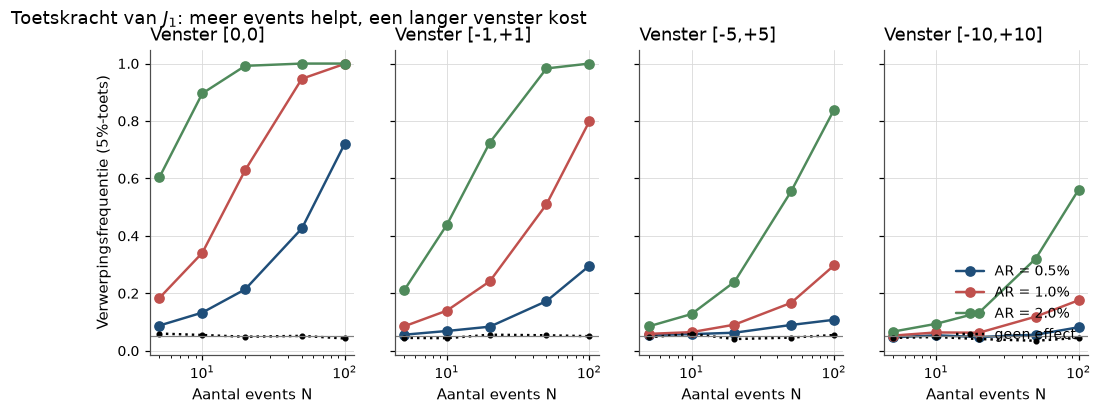

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(11, 3.6), sharey=True)
for ax, w in zip(axes, windows):
    sub = power[power["venster"] == w]
    for a in effects[1:]:
        s = sub[sub["AR dag 0"] == a]
        ax.plot(s["N"], s["verwerping"], marker="o", label=f"AR = {a:.1%}")
    s = sub[sub["AR dag 0"] == 0.0]
    ax.plot(s["N"], s["verwerping"], color="black", ls=":", marker=".", label="geen effect")
    ax.axhline(0.05, color="grey", lw=0.8)
    ax.set_xscale("log")
    ax.set_title(f"Venster {w}")
    ax.set_xlabel("Aantal events N")
axes[0].set_ylabel("Verwerpingsfrequentie (5%-toets)")
axes[-1].legend(loc="lower right")
fig.suptitle("Toetskracht van $J_1$: meer events helpt, een langer venster kost", x=0.01, ha="left")
plt.show()

:::{figure} #cel-eventstudies-kracht
:label: fig-eventstudies-kracht
:width: 100%

Toetskracht van $J_1$ in 1000 gesimuleerde steekproeven. Met een venster van één
dag vindt de toets een effect van 1% al in de meerderheid van de steekproeven met
20 events; met een venster van 21 dagen is dat effect zelfs met 100 events in vier
van de vijf steekproeven onzichtbaar. De stippellijn (geen effect) blijft rond 5%:
de toets is correct gespecificeerd, ook met dikke staarten.
:::

De kracht bij $N = 20$, $a = 1\%$ en een eendaags venster is 62,9%, tegen $61\%$
uit [](#eq-eventstudies-power). De omvang zonder effect ligt overal tussen 3,5 en
6%, binnen de simulatieruis van ongeveer $\pm 1{,}4$ procentpunt (zie ook
[](#ex-eventstudies-1)). En wie de eventdatum op een week nauwkeurig kent, heeft
vijf keer zoveel events nodig als wie hem op de dag kent.

Nu clustering. We zetten de gemeenschappelijke schok aan en kijken naar de
omvang — de verwerpingsfrequentie zonder effect — van de vier toetsen, voor een
eventvenster van drie dagen.

In [7]:
cluster_rows = []
for rho in [0.0, 0.02, 0.05, 0.10]:
    for n in [10, 25, 50, 100]:
        sim_c = simulate_events(reps=500, n_events=n, rho=rho, half=1)
        res = event_tests(sim_c, -1, 1)
        cluster_rows.append({"rho": rho, "N": n,
                             **{k: np.mean(np.abs(v) > 1.96) for k, v in res.items()},
                             "rho geschat": sim_c["rho_hat"].mean()})
cluster = pd.DataFrame(cluster_rows)
cluster["theorie J1"] = 2 * stats.norm.cdf(-1.96 / np.sqrt(1 + (cluster["N"] - 1) * cluster["rho"]))
cluster.round(3)

,rho,N,J1,J2,BMP,KP,rho geschat,theorie J1
0,0.00,10,0.046,0.040,0.054,0.058,0.000,0.050
1,0.00,25,0.058,0.056,0.080,0.078,0.000,0.050
2,0.00,50,0.054,0.060,0.050,0.050,-0.000,0.050
3,0.00,100,0.048,0.058,0.056,0.056,0.000,0.050
4,0.02,10,0.068,0.076,0.094,0.078,0.020,0.071
5,0.02,25,0.098,0.108,0.134,0.066,0.021,0.107
6,0.02,50,0.132,0.138,0.144,0.056,0.020,0.164
7,0.02,100,0.240,0.244,0.246,0.054,0.021,0.256
8,0.05,10,0.114,0.110,0.176,0.096,0.050,0.104
9,0.05,25,0.190,0.184,0.222,0.090,0.052,0.186


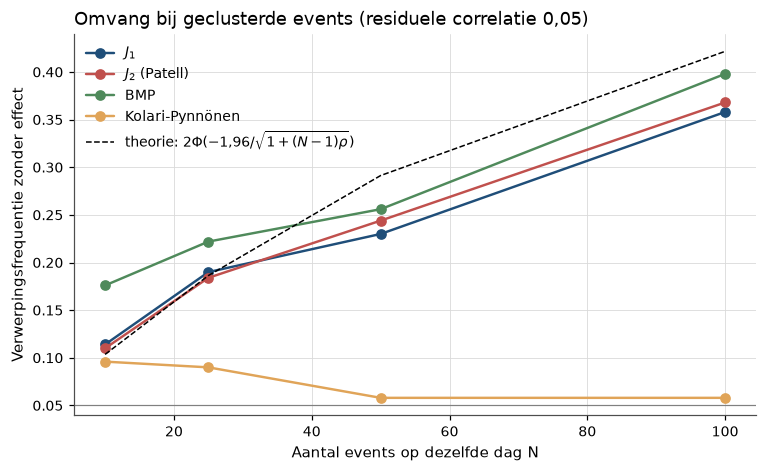

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sub = cluster[cluster["rho"] == 0.05]
for col, label in [("J1", "$J_1$"), ("J2", "$J_2$ (Patell)"), ("BMP", "BMP"),
                   ("KP", "Kolari-Pynnönen")]:
    ax.plot(sub["N"], sub[col], marker="o", label=label)
ax.plot(sub["N"], sub["theorie J1"], color="black", ls="--", lw=1,
        label="theorie: $2\\Phi(-1{,}96/\\sqrt{1+(N-1)\\rho})$")
ax.axhline(0.05, color="grey", lw=0.8)
ax.set_xlabel("Aantal events op dezelfde dag N")
ax.set_ylabel("Verwerpingsfrequentie zonder effect")
ax.set_title("Omvang bij geclusterde events (residuele correlatie 0,05)")
ax.legend()
plt.show()

:::{figure} #cel-eventstudies-clustering
:label: fig-eventstudies-clustering
:width: 85%

Als alle events op dezelfde dag vallen en de residuen onderling een correlatie van
0,05 hebben — bescheiden, vergelijkbaar met aandelen uit dezelfde sector — dan
verwerpen $J_1$, Patell en BMP de ware nulhypothese steeds vaker naarmate er meer
events zijn. De Kolari-Pynnönen-correctie brengt de omvang terug naar 5%, met een
correlatie die uit het schattingsvenster wordt geschat.
:::

De tabel bevestigt de richting en de orde van grootte van
[](#eq-eventstudies-cluster). De gesimuleerde omvang van $J_1$ ligt bij grote
$N\rho$ enkele procentpunten onder de normale benadering: het gemiddelde wordt dan
gedomineerd door de ene gemeenschappelijke schok, en die heeft hier een
$t_4$-verdeling, die bij ongeveer één standaarddeviatie minder overschrijdingen
heeft dan een normale. Bij $\rho = 0$ werken alle vier de toetsen. Een event dat
honderd banken tegelijk raakt, met residuele correlatie 0,10, geeft onder $J_1$
bijna de helft van de tijd een "significant" effect dat er niet is.

## Replicatie op echte data

```{admonition} Replicatie
:class: seealso

**Bron.** Fama, Fisher, Jensen & Roll, *The Adjustment of Stock Prices to New
Information*, International Economic Review 1969 {cite}`FamaFisherJensenRoll1969`.

**Wat.** Figuur 2 en Tabel 2: het cumulatieve gemiddelde residu $U_m$ (in onze
notatie de CAAR) in de maanden rond de maand waarin de splitsing ingaat, voor
alle splitsingen en voor de deelsteekproeven met en zonder dividendverhoging.

**Data hier.** Dagelijkse split- en dividendgecorrigeerde slotkoersen van 50 grote
Amerikaanse aandelen, 2002-01 t/m 2026-07, via `hap.data.yahoo(...)`; als
marktrendement de CRSP-value-weighted marktportefeuille uit de French-bibliotheek
(`hap.data.market_daily()`). De splitsingsdatums (ex-datum, ratio ≥ 3:2) komen uit
de split-historie van Yahoo Finance (`yfinance.Ticker.splits`, opgehaald
2026-09-12) en staan als lijst in de code, omdat `hap.data.yahoo` geen
corporate actions teruggeeft. Splitsingen die in feite een spin-off-correctie zijn
(ratio's als 1,05 of 1,32) zijn weggelaten.

**Verschil met het origineel.** FFJR gebruikten maanddata van 940
NYSE-splitsingen (622 aandelen) tussen januari 1927 en december 1959, met maand
0 de maand waarin de splitsing ingaat, en een marktmodel op log-rendementen ten
opzichte van Fisher's Combination Investment Performance Index, geschat met
uitsluiting van de maanden rond de splitsing. Wij gebruiken dagdata, 102
splitsingen, een eventvenster van $-250$ tot $+60$ handelsdagen, en schatten het
marktmodel net als FFJR buiten dat venster (maximaal 250 dagen ervoor en erna).
Onze aandelen zijn geselecteerd omdat ze *nu* groot zijn: een look-ahead-selectie
die het CAR vóór de splitsing opdrijft.

**Verwachte afwijking.** FFJR vonden (hun Figuur 2) een cumulatief gemiddeld
residu dat over de dertig maanden vóór de splitsing gestaag stijgt en in de
dertig maanden erna vrijwel vlak blijft; na splitsingen met een dividendverhoging
bleef het vlak, na splitsingen zonder daalde het in de eerste twaalf maanden. De
exacte waarden van $U_m$ in hun Tabel 2 konden we niet uit een toegankelijke bron
verifiëren en noemen we daarom niet. Wat identiek moet zijn, is de vorm:
een CAAR dat over het jaar vóór de ex-datum positief en significant is, en dat
na de ex-datum niet significant van nul verschilt ($|t| < 2$). Het
abnormale rendement op de ex-datum zelf moet nul zijn, want op die dag is er
niets nieuws. Door de selectie op huidige grootte verwachten we een grotere
stijging vóór de splitsing dan FFJR.
```

De lijst met splitsingen. Elke regel is `ticker:ex-datum:ratio`.

In [9]:
SPLITS = """
NFLX:2004-02-12:2/1 APH:2004-03-30:2/1 ODFL:2004-05-21:3/2 DHR:2004-05-21:2/1
PG:2004-06-21:2/1 QCOM:2004-08-16:2/1 BAC:2004-08-30:2/1 GILD:2004-09-07:2/1
CVX:2004-09-13:2/1 AAPL:2005-02-28:2/1 WRB:2005-04-11:3/2 ADBE:2005-05-24:2/1
UNH:2005-05-31:2/1 ORLY:2005-06-16:2/1 MNST:2005-08-09:2/1 SBUX:2005-10-24:2/1
FAST:2005-11-14:2/1 ODFL:2005-12-01:3/2 WRB:2006-04-05:3/2 NVDA:2006-04-07:2/1
MNST:2006-07-10:4/1 WFC:2006-08-14:2/1 CSX:2006-08-16:2/1 APH:2007-04-02:2/1
NKE:2007-04-03:2/1 GILD:2007-06-25:2/1 NVDA:2007-09-11:3/2 IDXX:2007-11-27:2/1
DE:2007-12-04:2/1 UNP:2008-05-29:2/1 BRK-B:2010-01-21:50/1 EW:2010-05-28:2/1
DHR:2010-06-14:2/1 ODFL:2010-08-24:3/2 TSCO:2010-09-03:2/1 FAST:2011-05-23:2/1
FTNT:2011-06-02:2/1 CSX:2011-06-16:3/1 ROST:2011-12-16:2/1 TJX:2012-02-03:2/1
MNST:2012-02-16:2/1 CPRT:2012-03-29:2/1 KO:2012-08-13:2/1 ODFL:2012-09-10:3/2
NKE:2012-12-26:2/1 GILD:2013-01-28:2/1 CRM:2013-04-18:4/1 TSCO:2013-09-27:2/1
MA:2014-01-22:10/1 AAPL:2014-06-09:7/1 UNP:2014-06-09:2/1 APH:2014-10-10:2/1
V:2015-03-19:4/1 SBUX:2015-04-09:2/1 ROST:2015-06-12:2/1 IDXX:2015-06-16:2/1
NFLX:2015-07-15:7/1 EW:2015-12-14:2/1 NKE:2015-12-24:2/1 MNST:2016-11-10:3/1
CPRT:2017-04-11:2/1 ISRG:2017-10-06:3/1 TJX:2018-11-07:2/1 WRB:2019-04-03:3/2
FAST:2019-05-23:2/1 ODFL:2020-03-25:3/2 EW:2020-06-01:3/1 AAPL:2020-08-31:4/1
TSLA:2020-08-31:5/1 APH:2021-03-05:2/1 SHW:2021-04-01:3/1 CSX:2021-06-29:3/1
NVDA:2021-07-20:4/1 ISRG:2021-10-05:3/1 ANET:2021-11-18:4/1 WRB:2022-03-24:3/2
AMZN:2022-06-06:20/1 DXCM:2022-06-13:4/1 FTNT:2022-06-23:5/1 GOOGL:2022-07-18:20/1
TSLA:2022-08-25:3/1 PANW:2022-09-14:3/1 CPRT:2022-11-04:2/1 MNST:2023-03-28:2/1
CPRT:2023-08-22:2/1 WMT:2024-02-26:3/1 ODFL:2024-03-28:2/1 NVDA:2024-06-10:10/1
APH:2024-06-12:2/1 CMG:2024-06-26:50/1 WRB:2024-07-11:3/2 AVGO:2024-07-15:10/1
CTAS:2024-09-12:4/1 SMCI:2024-10-01:10/1 LRCX:2024-10-03:10/1 ANET:2024-12-04:4/1
PANW:2024-12-16:2/1 TSCO:2024-12-20:5/1 FAST:2025-05-22:2/1 ORLY:2025-06-10:15/1
NFLX:2025-11-17:10/1 NOW:2025-12-18:5/1
"""
events = pd.DataFrame([tok.split(":") for tok in SPLITS.split()],
                      columns=["ticker", "ex_date", "ratio"])
events["ex_date"] = pd.to_datetime(events["ex_date"])
tickers = sorted(events["ticker"].unique())
print(f"{len(events)} splitsingen, {len(tickers)} aandelen, "
      f"{events['ex_date'].min():%Y-%m} t/m {events['ex_date'].max():%Y-%m}")

102 splitsingen, 50 aandelen, 2004-02 t/m 2025-12


In [10]:
prices = hap_data.yahoo(tickers, start="2002-01-01", end="2026-08-01")
market = hap_data.market_daily()["Mkt"].loc["2002-01-03":"2026-07-31"]
returns = prices.pct_change(fill_method=None).reindex(market.index)
print(f"rendementen: {returns.shape[0]} handelsdagen, {returns.index[0]:%Y-%m-%d} "
      f"t/m {returns.index[-1]:%Y-%m-%d}")

rendementen: 6183 handelsdagen, 2002-01-03 t/m 2026-07-31


Per event schatten we het marktmodel op het schattingsvenster, berekenen we de
abnormale rendementen over $\tau = -250, \dots, +60$, en bewaren we wat nodig is
voor de variantie van elk deel-CAR.

In [11]:
PRE, POST, EST = 250, 60, 250
tau = np.arange(-PRE, POST + 1)
dates = returns.index
r_m = market.to_numpy()

ar_rows, fits, resid_panel = [], [], np.full((len(dates), len(events)), np.nan)
for k, (ticker, ex_date) in enumerate(events[["ticker", "ex_date"]].itertuples(index=False)):
    r = returns[ticker].to_numpy()
    i0 = dates.searchsorted(ex_date)
    est = np.r_[max(i0 - PRE - EST, 0):i0 - PRE, i0 + POST + 1:min(i0 + POST + 1 + EST, len(dates))]
    est = est[np.isfinite(r[est])]
    coef, resid, s2, xtx_inv = fit_market_model(r[est], r_m[est])
    resid_panel[est, k] = resid
    window = np.arange(i0 - PRE, i0 + POST + 1)
    ar_rows.append(r[window] - coef[0] - coef[1] * r_m[window])
    fits.append({"ticker": ticker, "start": i0 - PRE, "L1": len(est), "beta": coef[1],
                 "sigma": np.sqrt(s2), "s2": s2, "xtx_inv": xtx_inv, "r_m": r_m[window]})

AR = np.array(ar_rows)
fit_table = pd.DataFrame(fits)[["ticker", "L1", "beta", "sigma"]]
fit_table.describe().loc[["mean", "min", "max"]].round(3)

,L1,beta,sigma
mean,495.0,1.078,0.018
min,343.0,0.237,0.007
max,500.0,2.668,0.053


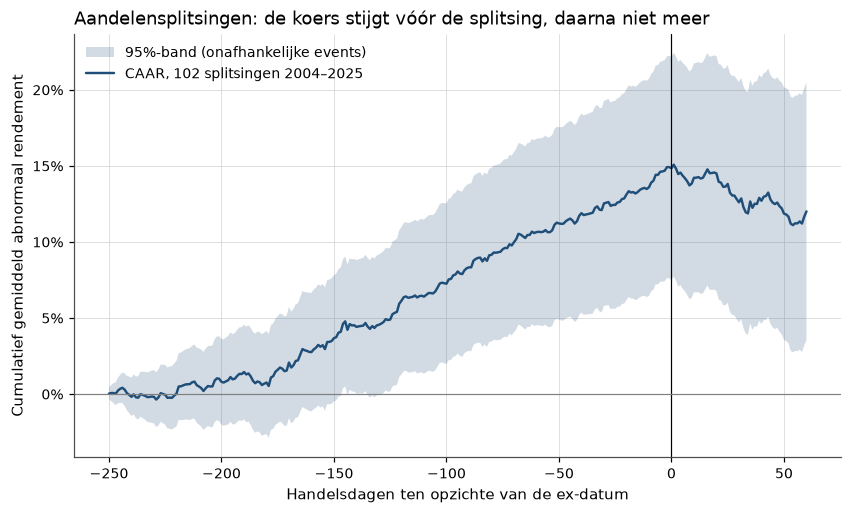

In [12]:
caar_path = AR.mean(axis=0).cumsum()
var_path = np.zeros(len(tau))
for f in fits:   # Var of CAR(-250, tau) per event, incl. estimation error, via cumulative sums
    g = np.column_stack([np.arange(1, len(tau) + 1), np.cumsum(f["r_m"])])
    var_path += f["s2"] * (g[:, 0] + np.einsum("ti,ij,tj->t", g, f["xtx_inv"], g))
se_path = np.sqrt(var_path) / len(fits)

fig, ax = plt.subplots()
ax.fill_between(tau, caar_path - 1.96 * se_path, caar_path + 1.96 * se_path,
                alpha=0.2, label="95%-band (onafhankelijke events)")
ax.plot(tau, caar_path, label="CAAR, 102 splitsingen 2004–2025")
ax.axvline(0, color="black", lw=0.8)
ax.axhline(0, color="grey", lw=0.8)
ax.set_xlabel("Handelsdagen ten opzichte van de ex-datum")
ax.set_ylabel("Cumulatief gemiddeld abnormaal rendement")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.set_title("Aandelensplitsingen: de koers stijgt vóór de splitsing, daarna niet meer")
ax.legend(loc="upper left")
plt.show()

:::{figure} #cel-eventstudies-caar
:label: fig-eventstudies-caar
:width: 90%

Cumulatief gemiddeld abnormaal rendement rond 102 splitsingen van grote Amerikaanse
aandelen. Het patroon is dat van FFJR: een gestage stijging over het jaar vóór de
splitsing, en geen voortgezette stijging erna. De band groeit met de wortel van de
vensterlengte plus de schattingsfoutterm; hij is gebaseerd op onafhankelijke events
en wordt in de tabel hieronder gecontroleerd op clustering.
:::

Nu de toetsen per venster. Voor de Kolari-Pynnönen-correctie schatten we de
residuele correlatie tussen elk paar events op de kalenderdagen waarop hun
schattingsvensters overlappen (minimaal 100 dagen), en wegen die met het deel van
het eventvenster dat beide events delen.

In [13]:
resid_corr = pd.DataFrame(resid_panel).corr(min_periods=100).to_numpy(copy=True)
np.fill_diagonal(resid_corr, np.nan)
starts = np.array([f["start"] for f in fits])


def split_tests(lo, hi):  # TODO: naar hap.stats
    """CAAR and J1 / BMP / Kolari-Pynnonen statistics over event window [lo, hi]."""
    cols = slice(lo + PRE, hi + PRE + 1)
    L2, n = hi - lo + 1, len(fits)
    car = AR[:, cols].sum(axis=1)
    var = np.array([car_variance(f["s2"], f["xtx_inv"], f["r_m"][cols]) for f in fits])
    scar = car / np.sqrt(var)
    a, b = starts + lo, starts + hi
    overlap = np.clip(np.minimum(b[:, None], b) - np.maximum(a[:, None], a) + 1, 0, None) / L2
    rho = np.nansum(overlap * np.nan_to_num(resid_corr)) / (n * (n - 1))
    bmp = scar.mean() / (scar.std(ddof=1) / np.sqrt(n))
    return {"venster": f"[{lo},{hi}]", "CAAR": car.mean(), "SE": np.sqrt(var.sum()) / n,
            "J1": car.mean() / (np.sqrt(var.sum()) / n), "BMP": bmp, "rho": rho,
            "KP": bmp * np.sqrt((1 - rho) / (1 + (n - 1) * rho)), "% positief": (car > 0).mean()}


table = pd.DataFrame([split_tests(lo, hi) for lo, hi in
                      [(-250, -1), (-250, -121), (-120, -1), (-1, 1), (0, 0), (1, 60), (0, 60)]])
table.set_index("venster").round(4)

,CAAR,SE,J1,BMP,rho,KP,% positief
venster,,,,,,,
"[-250,-1]",0.1493,0.0373,4.0024,4.7388,0.0012,4.4678,0.6471
"[-250,-121]",0.0594,0.0246,2.4165,2.6531,0.0007,2.5613,0.5490
"[-120,-1]",0.0898,0.0234,3.8324,4.7466,0.0007,4.5948,0.7157
"[-1,1]",0.0016,0.0033,0.4829,0.6761,0.0000,0.6753,0.5196
"[0,0]",-0.0008,0.0019,-0.3994,0.0545,0.0000,0.0544,0.5000
"[1,60]",-0.0284,0.0157,-1.8051,-1.2070,0.0003,-1.1866,0.4804
"[0,60]",-0.0292,0.0159,-1.8369,-1.1846,0.0003,-1.1641,0.4902


Het resultaat heeft de vorm die FFJR voorspelden. Over het jaar vóór de
ex-datum bedraagt het CAAR 14,9% (standaardfout 3,7 procentpunt), met $J_1 = 4{,}0$
en BMP $4{,}7$; bijna tweederde (65%) van de aandelen had een positief abnormaal
rendement. Op de ex-datum zelf is het gemiddelde abnormale
rendement $-0{,}08\%$ ($J_1 = -0{,}40$) — precies nul binnen de meetfout, zoals het hoort op een dag
zonder nieuws. Over de zestig dagen daarna is het CAAR $-2{,}9\%$ ($J_1 = -1{,}84$, BMP $-1{,}18$), niet significant
volgens BMP en Kolari-Pynnönen. Er is dus geen voortgezette winst te halen door
na de splitsing te kopen.

De nuance zit na de splitsing. FFJR vonden voor de volledige steekproef geen
drift; alleen splitsingen zonder dividendverhoging werden daarna afgestraft. Ons
CAAR van $-2{,}9\%$ met standaardfout 1,6 procentpunt is verenigbaar met hun
resultaat, maar ook met een negatieve drift van enkele procenten. Honderd events
zijn te weinig om dat te onderscheiden: het 2%-motief, in eventtijd. Hun eigen conclusie blijft de beste samenvatting:
*"once the information effects of associated dividends are properly considered,
a split per se has no net effect on common stock returns."*

Drie kanttekeningen. De stijging vóór de splitsing is deels de reden voor de
splitsing en deels onze selectie: wie in 2026 grote aandelen kiest, kiest
aandelen die sterk zijn gestegen — een bias die FFJR, met alle NYSE-splitsingen,
niet hadden. Verder meten wij rond de ex-datum, niet rond de aankondiging, die
enkele weken eerder valt; de informatie zit dus in $[-120, -1]$, en voor
aankondigingsdatums ontbreekt een gratis bron. Ten slotte is de geschatte
gemiddelde correlatie klein, omdat de splitsingen over twintig jaar verspreid
liggen (alleen in 2024 vallen er vijf binnen vijf weken); de
Kolari-Pynnönen-correctie verandert hier daarom weinig.

## Wat er brak, en wat daarna kwam

De event study is een van de meest succesvolle instrumenten die de empirische
financiering heeft voortgebracht. Ze maakte de semi-sterke vorm van
marktefficiëntie toetsbaar, en de uitkomst was over een halve eeuw en duizenden
studies opvallend consistent: op korte horizon reageren prijzen op publieke
informatie snel en in de goede richting, en na de aankondiging valt er met die
informatie weinig meer te verdienen. De splitsingen hierboven tonen het
opnieuw, zestig jaar na FFJR. Het instrument verhuisde naar het recht, de
bedrijfsfinanciering en de macro-economie, en werd in 2023 gebruikt om de waarde
van generatieve AI te meten: {cite:t}`EisfeldtSchubertZhang2023` gebruikten de introductie van
ChatGPT op 30 november 2022 als event. Hun portefeuille die long gaat in
bedrijven waarvan het werk sterk aan generatieve AI is blootgesteld en short in
bedrijven waarvoor dat niet geldt, verdiende 0,45% per dag ($t = 3{,}53$) en
volgens hun samenvatting 5% in de twee weken na de lancering — een lijn die we in [de lecture over LLM's](#07-37-llms-en-efficientie)
weer oppakken.

De barst zit in de lange horizon. Latere studies vonden *drift* (een abnormaal
rendement dat na het event in dezelfde richting doorloopt) na
winstaankondigingen, emissies, inkoopprogramma's en splitsingen; onze eigen tabel
laat na de ex-datum $-2{,}9\%$ zien, niet significant maar ook niet nul. Hier bijt
de joint hypothesis: de bias van een verkeerd benchmarkmodel groeit lineair in de
horizon en de ruis met de wortel, dus een abnormaal rendement over drie jaar is
evenveel een uitspraak over het model als over de markt.

Die drift laat zich op twee manieren lezen, en de data scheiden de lezingen niet.
In de Chicago-lezing is de drift een beloning voor risico dat het marktmodel niet
meet: aandelen die splitsen of hun winst verrassend zien stijgen, veranderen van
risicoprofiel, en een beter model voor het normale rendement zou de drift doen
verdwijnen. In de Yale-lezing is de drift een vergissing: beleggers reageren te
traag op nieuws, en de arbitrage die de vergissing zou moeten wegwerken is te
riskant of te duur om de koers in één keer op zijn plaats te zetten. Beide
lezingen voorspellen hetzelfde CAR-patroon. Om ze te scheiden is precies nodig
wat de event study niet levert: een onomstreden model voor het verwachte
rendement.

Dat model was er al, als theorie. Sharpe, Lintner en Mossin hadden het in het
midden van de jaren zestig afgeleid {cite}`Sharpe1964,Lintner1965,Mossin1966`, en
Jensen gebruikte het in 1968 {cite}`Jensen1968` om
beleggingsfondsen te beoordelen. De vraag of het ook empirisch klopte — of beta
werkelijk het verwachte rendement bepaalt — werd het hoofdonderwerp van het
volgende decennium: [het CAPM](#02-08-capm).

## Oefeningen

:::{exercise}
:label: ex-eventstudies-1

**De prijs van het vergeten van de schattingsfout.**

1. Leid voor het *constant-mean*-model $R_{i,\tau} = \mu_i + \varepsilon_{i,\tau}$
   af dat $\Var(\widehat{\text{CAR}}_i) = \sigma^2_{\varepsilon_i}(L_2 + L_2^2/L_1)$.
2. Laat zien dat de naïeve toets, die $L_2\sigma^2$ gebruikt, een werkelijke
   standaarddeviatie heeft van $\sqrt{1 + L_2/L_1}$. Hoe groot is de werkelijke
   omvang van een nominale 5%-toets voor $L_2 = 21$ en $L_1 = 60$, $120$, $250$?
3. Controleer (2) met `sim0`: bereken voor het venster $[-10, +10]$ en $N = 100$ de
   omvang van $J_1$ met en zonder de correctietermen.
:::

:::{solution} ex-eventstudies-1
:class: dropdown

**(1)** Met alleen een constante is $\mathbf{X}_i = \boldsymbol{\iota}$ en
$(\mathbf{X}_i'\mathbf{X}_i)^{-1} = 1/L_1$. Met $\mathbf{g} = L_2$ geeft
[](#thm-eventstudies-ar) $\sigma^2_{\varepsilon_i}(L_2 + L_2^2/L_1)$. Intuïtief:
$\hat\mu_i$ heeft variantie $\sigma^2/L_1$, en die fout wordt $L_2$ keer opgeteld,
dus $L_2^2\sigma^2/L_1$.

**(2)** De werkelijke variantie gedeeld door de gebruikte is
$(L_2 + L_2^2/L_1)/L_2 = 1 + L_2/L_1$. De omvang is
$2\Phi\bigl(-1{,}96/\sqrt{1 + L_2/L_1}\bigr)$.

In [14]:
for L1_ in [60, 120, 250]:
    print(f"L1 = {L1_:3d}: werkelijke omvang = {2 * stats.norm.cdf(-1.96 / np.sqrt(1 + 21 / L1_)):.3f}")

L1 =  60: werkelijke omvang = 0.092
L1 = 120: werkelijke omvang = 0.071
L1 = 250: werkelijke omvang = 0.060


**(3)**

In [15]:
h = sim0["half"]
car = sim0["ar"][:, :, h - 10:h + 11].sum(-1)
var_naive = sim0["s2"] * 21
J1_naive = car.sum(1) / np.sqrt(var_naive.sum(1))
J1_full = event_tests(sim0, -10, 10)["J1"]
print(f"omvang zonder correctie: {np.mean(np.abs(J1_naive) > 1.96):.3f}")
print(f"omvang met correctie   : {np.mean(np.abs(J1_full) > 1.96):.3f}")

omvang zonder correctie: 0.052
omvang met correctie   : 0.045


Bij $L_1 = 250$ is de vertekening klein, bij $L_1 = 60$ — een venster dat men in
de praktijk tegenkomt bij recente beursintroducties — verwerpt de naïeve toets
bijna twee keer te vaak. De les: de variantie van een abnormaal rendement is niet
alleen de ruis van de eventdag, maar ook de onzekerheid over wat normaal was.
:::

:::{exercise}
:label: ex-eventstudies-2

**Brown-Warner op echte data.** Gebruik de rendementen `returns` en `market` uit de
replicatie. Trek 300 keer een steekproef van 20 pseudo-events: een willekeurig
aandeel en een willekeurige handelsdag tussen 2004 en 2025 met een volledig
schattingsvenster van 250 dagen ervóór. Schat het marktmodel, en bereken $J_1$
voor een eendaags venster zonder effect en met een geïnjecteerd abnormaal
rendement van 1%. Vergelijk omvang en kracht met de simulatie
([](#fig-eventstudies-kracht)). Welke eigenschap van echte data verklaart een
eventueel verschil?
:::

:::{solution} ex-eventstudies-2
:class: dropdown

In [16]:
first, last = dates.searchsorted(pd.Timestamp("2004-01-01")), dates.searchsorted(pd.Timestamp("2025-12-31"))
J_null, J_alt = [], []
for _ in range(300):
    num, var_sum = 0.0, 0.0
    for _ in range(20):
        while True:
            r = returns[tickers[rng.integers(len(tickers))]].to_numpy()
            i0 = rng.integers(first, last)
            est = np.arange(i0 - 250, i0)
            if np.isfinite(r[est]).all() and np.isfinite(r[i0]):
                break
        coef, _, s2, xtx_inv = fit_market_model(r[est], r_m[est])
        num += r[i0] - coef[0] - coef[1] * r_m[i0]
        var_sum += car_variance(s2, xtx_inv, r_m[i0:i0 + 1])
    J_null.append(num / np.sqrt(var_sum))
    J_alt.append((num + 20 * 0.01) / np.sqrt(var_sum))
print(f"omvang (geen effect): {np.mean(np.abs(J_null) > 1.96):.3f}")
print(f"kracht (AR = 1%)    : {np.mean(np.abs(J_alt) > 1.96):.3f}")

omvang (geen effect): 0.053
kracht (AR = 1%)    : 0.687


De omvang ligt dicht bij 5%, want willekeurige data en aandelen geven vrijwel
onafhankelijke events. De kracht ligt iets hoger dan de 63% van de simulatie met
$N = 20$, vooral omdat de gemiddelde residuele volatiliteit van deze grote
aandelen (1,8%) onder de 2% van de simulatie ligt. De spreiding in volatiliteit
werkt de andere kant op: een paar zeer volatiele aandelen (TSLA, SMCI) domineren
de noemer van $J_1$. De les: de conclusie van Brown en Warner hangt niet aan de
simulatieaannames.
:::

:::{exercise}
:label: ex-eventstudies-3

**Het bad model problem.** Neem aan dat het model voor het normale rendement elk
aandeel per dag $\delta = 0{,}02\%$ te laag inschat (bijvoorbeeld een gemiste
size-premie), met residuele volatiliteit $\sigma = 2\%$ en onafhankelijke events.

1. Bereken met de formule uit de theorie de verwachte $J_1$ en de omvang van een
   nominale 5%-toets voor $N = 100$ en horizons $H = 1, 21, 250, 750$ dagen.
2. Controleer met een simulatie (2000 replicaties, normale residuen).
3. Hoe groot moet $\delta$ zijn opdat een driejarige event study met 100 events in
   de helft van de gevallen een vals effect vindt? Vertaal het antwoord naar een
   jaarlijkse fout in het verwachte rendement.
:::

:::{solution} ex-eventstudies-3
:class: dropdown

**(1) en (2)** Onder het alternatief is $J_1 \sim \mathcal{N}(\sqrt{NH}\,\delta/\sigma, 1)$.

In [17]:
n_ev, sigma, delta = 100, 0.02, 0.0002
rows = []
for H in [1, 21, 250, 750]:
    mean_J = np.sqrt(n_ev * H) * delta / sigma
    theory = stats.norm.cdf(mean_J - 1.96) + stats.norm.cdf(-mean_J - 1.96)
    # the average of N independent H-day CARs is normal with mean H*delta, sd sigma*sqrt(H/N)
    caar = rng.normal(H * delta, sigma * np.sqrt(H / n_ev), size=2000)
    J = caar / (sigma * np.sqrt(H / n_ev))
    rows.append({"H": H, "E[J1]": mean_J, "omvang theorie": theory,
                 "omvang simulatie": np.mean(np.abs(J) > 1.96)})
pd.DataFrame(rows).round(3)

,H,E[J1],omvang theorie,omvang simulatie
0,1,0.100,0.051,0.052
1,21,0.458,0.074,0.073
2,250,1.581,0.353,0.352
3,750,2.739,0.782,0.790


**(3)** Een verwerpingskans van 50% vereist $\sqrt{NH}\,\delta/\sigma \approx 1{,}96$,
dus $\delta = 1{,}96 \times 0{,}02/\sqrt{75\,000} = 0{,}0143\%$ per dag, ofwel
ongeveer 3,6% per jaar. Dat is kleiner dan de gemeten verschillen tussen kleine en
grote aandelen of tussen value en groei. Een driejarige event study die geen
rekening houdt met die kenmerken, meet dus eerder het benchmarkmodel dan het
event. Dit is waarom de lange-horizonliteratuur onvermijdelijk een discussie
over asset-pricingmodellen werd.
:::